In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
data = pd.read_csv('Salary_dataset.csv')
x_name = 'YearsExperience'
y_name = 'Salary'

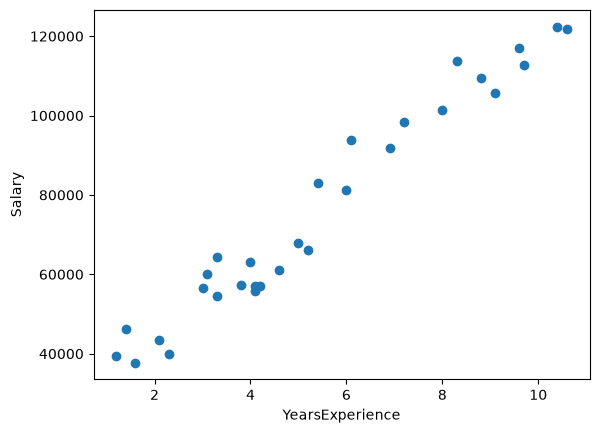

In [27]:
plt.scatter(data[x_name], data[y_name])
plt.xlabel(x_name)
plt.ylabel(y_name)
plt.show()

Epoch: 0 | Current Error: 167268035982.27
Epoch: 0 | Current Improvement: 27825182349.73
Epoch: 500 | Current Error: 3138481071.41
Epoch: 500 | Current Improvement: 1809811.94
Epoch: 1000 | Current Error: 2396808123.39
Epoch: 1000 | Current Improvement: 1199778.53
Epoch: 1500 | Current Error: 1905130917.82
Epoch: 1500 | Current Improvement: 795369.11
Epoch: 2000 | Current Error: 1579183375.69
Epoch: 2000 | Current Improvement: 527274.00
Epoch: 2500 | Current Error: 1363102989.97
Epoch: 2500 | Current Improvement: 349545.72
Epoch: 3000 | Current Error: 1219856832.07
Epoch: 3000 | Current Improvement: 231724.33
Epoch: 3500 | Current Error: 1124894664.69
Epoch: 3500 | Current Improvement: 153616.99
Epoch: 4000 | Current Error: 1061941400.44
Epoch: 4000 | Current Improvement: 101837.31
Epoch: 4500 | Current Error: 1020207796.51
Epoch: 4500 | Current Improvement: 67511.00
Epoch: 5000 | Current Error: 992541340.82
Epoch: 5000 | Current Improvement: 44755.06
Epoch: 5500 | Current Error: 97420

Text(0, 0.5, 'Salary')

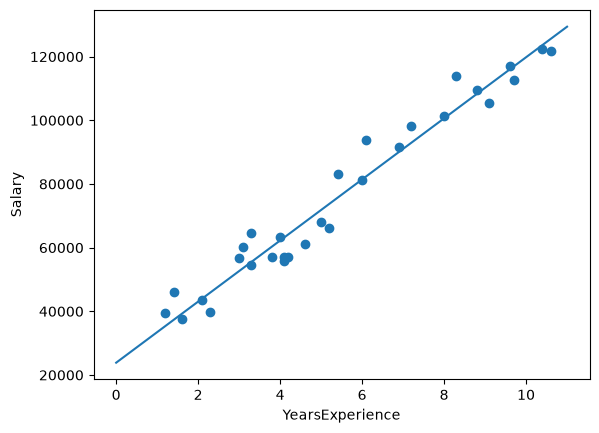

In [43]:
def sumofsquare(m, b, points):
    res = 0

    n = len(points)

    for i in range(n):
        x = points[x_name].iloc[i]
        y = points[y_name].iloc[i]
        y_predict = m * x + b
        res += (y_predict - y) ** 2

    return res


def gradient_discent(m_now, b_now, points, L):
    m_gradient = 0
    b_gradient = 0

    n = len(points)

    for i in range(n):
        x = points[x_name].iloc[i]
        y = points[y_name].iloc[i]

        m_gradient += x * (y - (m_now * x + b_now))
        b_gradient += y - (m_now * x + b_now)

    m_gradient *= (-2 / n)
    b_gradient *= (-2 / n)

    m = m_now - L * m_gradient
    b = b_now - L * b_gradient

    return m, b

m = 0
b = 0
L = 0.001
epochs = 10000
tolerance = 5000

previous_error = sumofsquare(m, b, data)

for i in range(epochs):
    m, b = gradient_discent(m, b, data, L)

    current_error = sumofsquare(m, b, data)

    improvement = previous_error - current_error

    if(abs(improvement) < tolerance):
        print(f"Converged! The minimum error was reached at Epoch {i}.")
        break

    previous_error = current_error

    if i % 500 == 0: 
        print(f"Epoch: {i} | Current Error: {current_error:.2f}")
        print(f"Epoch: {i} | Current Improvement: {improvement:.2f}")

ss_mean = sumofsquare(0, data['Salary'].mean(), data)
ss_lr = sumofsquare(m, b, data)

r_square = (ss_mean - ss_lr) / ss_mean

print(f"R Square: {r_square}")
print(f"Variation: {ss_lr / len(data)}")

plt.scatter(data['YearsExperience'], data['Salary'])
plt.plot(list(range(0, 12)), [m * x + b for x in range(0, 12)])
plt.xlabel('YearsExperience')
plt.ylabel('Salary')